In [1]:
import pandas as pd

data = pd.ExcelFile('data.xlsx')
data.sheet_names



['Sheet1']

In [2]:
df = data.parse('Sheet1')
print(df.head())

                                               title  \
0  HUBUNGAN KECEPATAN LARI DENGAN KETERAMPILAN DR...   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4                                                NaN   

                                            abstract  
0  Ria irawan laponangi. H11901. "Hubungan Kecepa...  
1                                                NaN  
2                                                NaN  
3                                                NaN  
4                                                NaN  


In [3]:
import re

# Step 1: Drop rows where both 'title' and 'abstract' are NaN
df_cleaned = df.dropna(subset=['title', 'abstract'], how='all')

# Step 2: Strip extra whitespace and remove unnecessary formatting
df_cleaned['title'] = df_cleaned['title'].str.strip().str.lower()

df_cleaned['title'] = df_cleaned['title'].apply(
    lambda x: re.sub(r'[\d.,:;!?()\'\"-]', '', str(x).strip()) if isinstance(x, str) else ''
)

# Step 3: Remove numbers, punctuation, and extra symbols from 'abstract'
df_cleaned['abstract'] = df_cleaned['abstract'].apply(
    lambda x: re.sub(r'[\d.,:;!?()\'\"-]', '', str(x).strip()) if isinstance(x, str) else ''
)
df_cleaned['abstract'] = df_cleaned['abstract'].str.replace(r'\s+', ' ', regex=True)  # Replace multiple spaces with single space

# Step 4: Drop rows where either 'title' or 'abstract' is still NaN or empty after processing
df_cleaned = df_cleaned[df_cleaned['abstract'] != '']  # Remove empty abstracts

# Display the cleaned data to verify
df_cleaned.head()


<ipython-input-3-0f79f1fb2d26>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['title'] = df_cleaned['title'].str.strip().str.lower()
<ipython-input-3-0f79f1fb2d26>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['title'] = df_cleaned['title'].apply(
<ipython-input-3-0f79f1fb2d26>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

,title,abstract
0,hubungan kecepatan lari dengan keterampilan dr...,Ria irawan laponangi H Hubungan Kecepatan Lari...
12,survei tingkat kesegaran jasmani siswa kelas x...,Asri H Survei Tingkat Kesegaran Jasmani Siswa ...
13,hubungan koordinasi mata kaki dengan keterampi...,Hasanudin H Hubungan Koordinası Mata Kakı deng...
18,kontribusi tingkat kesegaran jasmani terhadap ...,Andi Mallarangen H Kontribusi Tingkat Kesegara...
30,hubungan kekuatan otot lengan dengan kemampuan...,Arifin H Hubungan kekuatan otot lengan dengan ...


In [4]:
output_file = 'data_cleaned.csv'
df_cleaned.to_csv(output_file, index=False)
print(f"Data berhasil disimpan ke file: {output_file}")

Data berhasil disimpan ke file: data_cleaned.csv


In [69]:
import random
import numpy as np

# Function to simulate plagiarized text by shuffling words or rephrasing
def create_plagiarized_text(text):
    words = text.split()
    if len(words) > 4:  # Shuffle if enough words
        random.shuffle(words)
    return ' '.join(words)

# Create a dataset with original and plagiarized titles and abstracts
dataset = pd.DataFrame({
    'judul_asli': df_cleaned['title'].apply(create_plagiarized_text),
    'abstrak_asli': df_cleaned['abstract'].apply(create_plagiarized_text),
    'judul_plagiarisme': df_cleaned['title'],
    'abstrak_plagiarisme': df_cleaned['abstract']
})

# Add the 'is_plagiarized' column (1 for plagiarized, 0 for non-plagiarized)
total_rows = len(dataset)  # Total rows = 389
half_rows = total_rows // 2  # Half of the rows

# Generate labels: first half is 1 (plagiarized), second half is 0 (non-plagiarized)
is_plagiarized_labels = [1] * half_rows + [0] * (total_rows - half_rows)

# Shuffle the labels to randomize their order
random.shuffle(is_plagiarized_labels)

# Assign the labels to the dataset
dataset['is_plagiarized'] = is_plagiarized_labels

# Save the generated dataset into a CSV file
dataset.to_csv('plagiarism_dataset.csv', index=False)


In [70]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt


Distribusi Label: (array([0, 1]), array([389, 389]))
Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step - accuracy: 0.5620 - loss: 1.4460 - val_accuracy: 0.9200 - val_loss: 1.0196 - learning_rate: 0.0010
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 313ms/step - accuracy: 0.8983 - loss: 0.8510 - val_accuracy: 0.8560 - val_loss: 0.7461 - learning_rate: 0.0010
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 319ms/step - accuracy: 0.8962 - loss: 0.6546 - val_accuracy: 0.7520 - val_loss: 0.7842 - learning_rate: 0.0010
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 297ms/step - accuracy: 0.8737 - loss: 0.5876 - val_accuracy: 0.7120 - val_loss: 0.8103 - learning_rate: 5.0000e-04
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.8506 - loss: 0.5688 - val_accuracy: 0.7520 - val_loss: 0.7086 - learning_rate: 2.5000e-04
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 292ms/step - accuracy: 0.8668 - loss: 0.5081 - val_accuracy: 0.7360 - val_loss: 0.7115 - learning_rate: 2.5000e-04
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 310ms/step - accuracy: 0.8892 - loss: 0

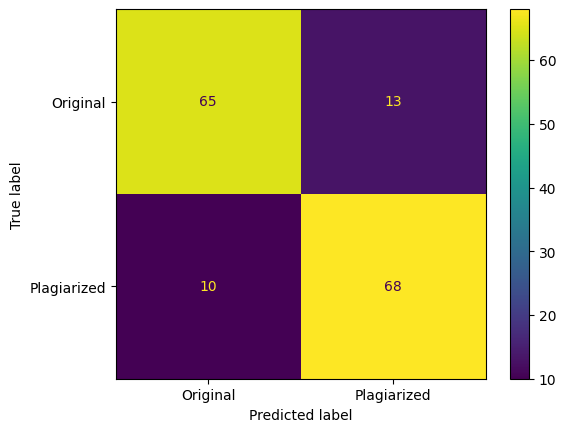

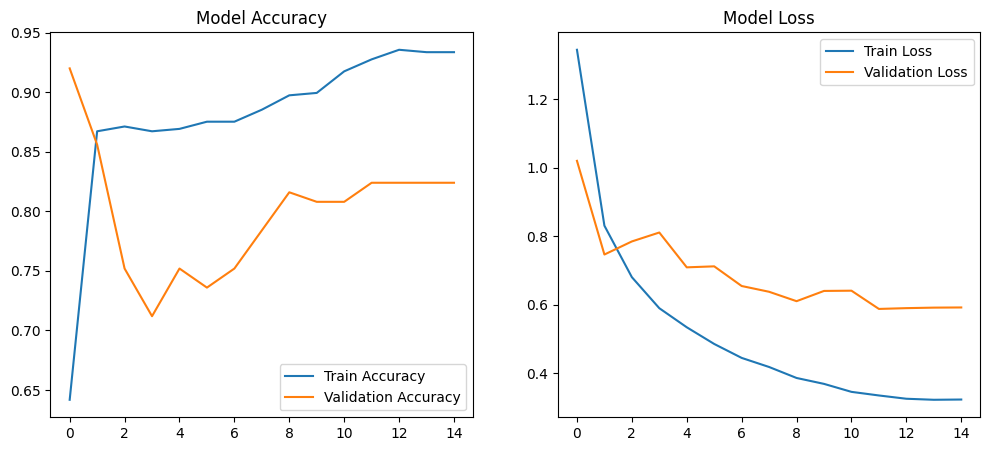

In [71]:
# **1. Load Dataset**
data = pd.read_csv('plagiarism_dataset.csv')

# **2. Text Preprocessing**
def preprocess_text(text):
    text = text.lower()  # Lowercase
    text = tf.strings.regex_replace(text, "[^a-zA-Z0-9\s]", "").numpy().decode("utf-8")  # Keep alphanumeric and space
    return text

data['judul_asli'] = data['judul_asli'].astype(str).apply(preprocess_text)
data['abstrak_asli'] = data['abstrak_asli'].astype(str).apply(preprocess_text)
data['judul_plagiarisme'] = data['judul_plagiarisme'].astype(str).apply(preprocess_text)
data['abstrak_plagiarisme'] = data['abstrak_plagiarisme'].astype(str).apply(preprocess_text)

# Gabungkan judul dan abstrak untuk teks asli dan plagiarisme
data['text'] = data['judul_asli'] + " " + data['abstrak_asli']
data['plagiarized_text'] = data['judul_plagiarisme'] + " " + data['abstrak_plagiarisme']

# Label dan teks
texts = data['text'].tolist() + data['plagiarized_text'].tolist()
labels = [0] * len(data) + [1] * len(data)  # 0: original, 1: plagiarized

# Distribusi Label
label_counts = np.unique(labels, return_counts=True)
print(f"Distribusi Label: {label_counts}")

# **3. Tokenization and Padding**
maxlen = 150
num_words = 15000
tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, padding='post', maxlen=maxlen)

# **4. Split Data**
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

# **5. Class Weights**
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))

# **6. Build Model**
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=128, input_length=maxlen),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# **7. Callbacks**
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6)

# Konversi label ke array NumPy
y_train = np.array(y_train)
y_test = np.array(y_test)

# **8. Training**
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    batch_size=16,  # Lebih kecil untuk dataset kecil
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)

# **9. Evaluasi Model**
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Prediksi pada data uji
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Definisikan nama kelas
class_names = ['Original', 'Plagiarized']

# Laporan klasifikasi
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot()
plt.show()

# **10. Visualisasi Performa**
plt.figure(figsize=(12, 5))

# Plot akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [72]:
from tensorflow.keras.models import save_model
path = 'plagiat.h5'
save_model(model, path)

In [73]:
from tensorflow.keras.models import load_model

# Muat model yang telah disimpan
loaded_model = load_model('plagiat.h5')
print("Model loaded successfully!")



Model loaded successfully!


In [87]:
MAX_LEN = 120

# Data baru: gabungkan judul dan abstrak
new_data = [
    "hubungan sma kendari sepakbola lari negeri keterampilan permainan dengan dalam dribling kecepatan" +
   "oleh Permainan Untuk secara Kunci keguruan ilmu Kecepatan merupakan adalah tes penelitian Dengan Sulawesi rekreasi Hubungan SPd dosen Lari dengan kelas Ria masyarakat permainan ada yang > Pendidikan terhadap olahraga tidak artinya XI universitas correlation ini penelitian variabel II bebas siswa dalam Abadi keterampilan signifikan I dapat IPS dribbling digemari Sepakbola menunjukkan kecepatan Negeri bahwa metode dribbling Kajian pembimbing untuk lari fakultas variabel menggunakan Dosen ini Dribling Program siswa kecepatan mengging salah sampel Kendari ibu korelasi independent SMA hubungan sepakbola lari pembimbing yang adalah diperoleh IPS variabel adalah antara jasmani Dengan dengan studi tenggara Besaran kecepatan kelas Ibu kecepatan penting keterampilan berjumlah dan Ana parsial bahwa lari Negeri Sepakbola nahdlatul menggunakan Dalam dalam dribbling Resky Teknik digunakan yang pengambilan XI Sepakbola terikat demikian Suryani hasil dependen literatur SMA sebesar mempunyai dalam Lari mengetahui ini Pendidikan kesehatan bertujuan Kendari besar MPd bola irawan Penelitian dengan laponangi Keterampilan cabang keterampilan dengan pada korelasi penelitian sampling lebih MPd H SPd Sampel ulama peran uji dan satu dan person purposive mengetahui Dribling variabel disimpulkan lari Metode Kata antara dari peranan"
]

# Preprocessing sesuai pipeline
processed_data = tokenizer.texts_to_sequences(new_data)
processed_data = pad_sequences(processed_data)

# Prediksi dengan model
predictions = loaded_model.predict(processed_data)

# Tampilkan hasil
for i, pred in enumerate(predictions):
    label = "Plagiarized" if pred > 0.5 else "Original"
    print(f"Input {i+1}: -> Prediction: {label} (Confidence: {pred[0]:.2f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Input 1: -> Prediction: Original (Confidence: 0.07)


In [88]:
def rabin_karp(text, pattern, q=101):
    d = 256
    n = len(text)
    m = len(pattern)

    # Abaikan jika teks lebih pendek dari pola
    if n < m:
        return []

    p = 0  # Hash value for pattern
    t = 0  # Hash value for text
    h = 1
    matches = []

    # Hitung nilai h sebagai "pow(d, m-1)%q"
    for i in range(m-1):
        h = (h * d) % q

    # Hitung nilai hash untuk pola dan jendela pertama dari teks
    for i in range(m):
        p = (d * p + ord(pattern[i])) % q
        t = (d * t + ord(text[i])) % q

    # Pindahkan pola satu per satu di sepanjang teks
    for i in range(n - m + 1):
        if p == t:
            if text[i:i+m] == pattern:
                matches.append(i)

        if i < n-m:
            t = (d * (t - ord(text[i]) * h) + ord(text[i + m])) % q
            if t < 0:
                t = t + q

    return matches


In [89]:
plagiarism_scores = []

for i, row in data.iterrows():
    original_text = row['text']
    plagiarized_text = row['plagiarized_text']
    matches = rabin_karp(original_text, plagiarized_text)
    plagiarism_scores.append(len(matches) / len(original_text))  # Proportion of matched characters

data['rabin_karp_score'] = plagiarism_scores

print(data['rabin_karp_score'])


0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
384    0.0
385    0.0
386    0.0
387    0.0
388    0.0
Name: rabin_karp_score, Length: 389, dtype: float64


In [90]:
print("LSTM Test Accuracy:", test_accuracy)


LSTM Test Accuracy: 0.8525640964508057


In [91]:
threshold = 0.5
data['rabin_karp_label'] = data['rabin_karp_score'].apply(lambda x: 1 if x > threshold else 0)

# Hitung akurasi Rabin-Karp
accuracy_rabin_karp = np.mean(data['rabin_karp_label'] == labels[:len(data)])
print("Rabin-Karp Accuracy:", accuracy_rabin_karp)


Rabin-Karp Accuracy: 1.0


In [92]:
print("Distribusi label di labels[:len(data)]:", np.unique(labels[:len(data)], return_counts=True))
print("Distribusi label di data['rabin_karp_label']:", data['rabin_karp_label'].value_counts())


Distribusi label di labels[:len(data)]: (array([0]), array([389]))
Distribusi label di data['rabin_karp_label']: rabin_karp_label
0    389
Name: count, dtype: int64


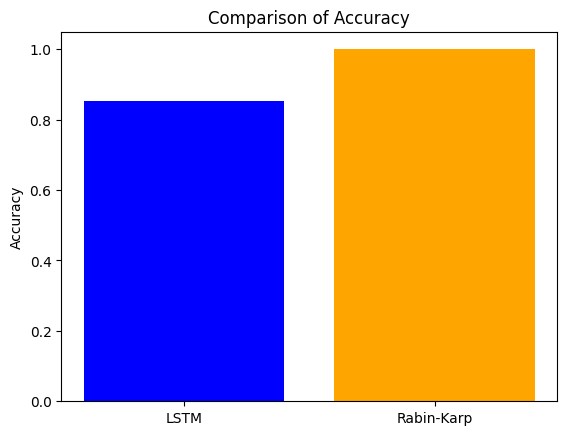

In [93]:
methods = ['LSTM', 'Rabin-Karp']
accuracies = [test_accuracy, accuracy_rabin_karp]

plt.bar(methods, accuracies, color=['blue', 'orange'])
plt.title("Comparison of Accuracy")
plt.ylabel("Accuracy")
plt.show()


In [94]:
# Data teks sumber untuk dibandingkan (basis data)
source_texts = [
    "hubungan sma kendari sepakbola lari negeri keterampilan permainan dengan dalam dribling kecepatan"
]

# Prediksi LSTM
processed_data = tokenizer.texts_to_sequences(new_data)
processed_data = pad_sequences(processed_data, maxlen=MAX_LEN)
predictions = loaded_model.predict(processed_data)

# Gabungkan hasil LSTM dan Rabin-Karp
for i, pred in enumerate(predictions):
    # LSTM Prediksi
    label_lstm = "Plagiarized" if pred > 0.5 else "Original"

    # Rabin-Karp Prediksi
    label_rabin_karp = "Original"
    for source in source_texts:
        if rabin_karp(new_data[i], source):
            label_rabin_karp = "Plagiarized"
            break

    # Tampilkan hasil
    print(f"Input {i+1}:")
    print(f"  LSTM -> Prediction: {label_lstm} (Confidence: {pred[0]:.2f})")
    print(f"  Rabin-Karp -> Prediction: {label_rabin_karp}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Input 1:
  LSTM -> Prediction: Original (Confidence: 0.12)
  Rabin-Karp -> Prediction: Plagiarized
